In [1]:
pip install numpy pandas scipy statsmodels matplotlib bootstrapped

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 95.7 MB/s eta 0:00:00
  Created wheel for bootstrapped: filename=bootstrapped-0.0.2-py2.py3-none-any.whl size=13932 sha256=2fdf7ed0e31259d7c83821f90e01445df60306c5010c7547cf156d8a9a0140d4
  Stored in directory: /home/huenique/.cache/pip/wheels/27/f5/64/e468cabb82d6c54c3697bef842edb42501d697b7c40c79d6c5
Successfully built bootstrapped
Note: you may need to restart the kernel to use updated packages.


KS Test Statistic: 0.059, P-value: 0.06153429181321559
Bootstrap Mean Difference: 0.0235418118624578
Bootstrap Confidence Interval: 0.020432466776710977, 0.026650672882241332


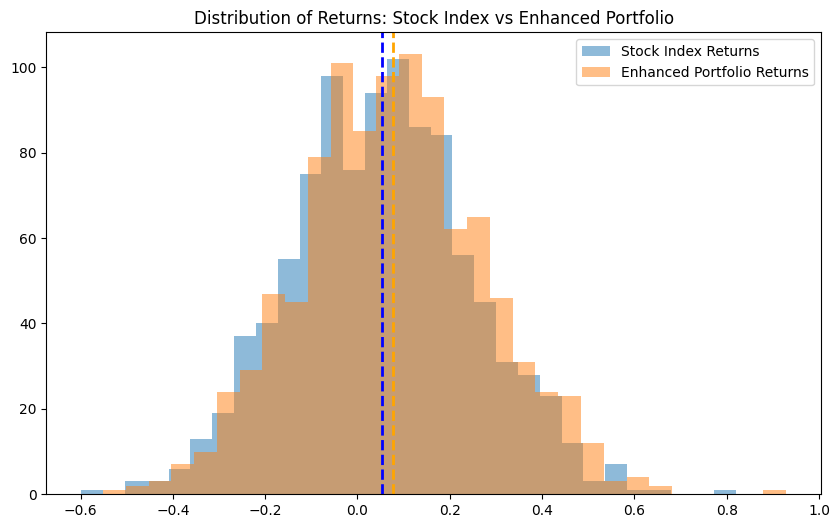

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from bootstrapped import bootstrap as bs
from bootstrapped import stats_functions as bs_stats

# Example: Simulating returns for enhanced portfolio and stock index
np.random.seed(42)  # For reproducibility

# Generate some sample data (replace this with actual data)
index_returns = np.random.normal(0.05, 0.2, 1000)  # Stock index returns
enhanced_returns = index_returns + np.random.normal(0.02, 0.05, 1000)  # Enhanced portfolio returns

# Step 3: Perform Statistical Tests (Linton et al. Kolmogorov-Smirnov Test for SSD)
def kolmogorov_smirnov_test(index_returns, enhanced_returns):
    """
    Perform Kolmogorov-Smirnov test for SSD dominance.
    """
    ks_statistic, p_value = ks_2samp(enhanced_returns, index_returns)
    print(f"KS Test Statistic: {ks_statistic}, P-value: {p_value}")
    return ks_statistic, p_value

# Perform the KS test
ks_stat, p_value = kolmogorov_smirnov_test(index_returns, enhanced_returns)

# Step 4: Bootstrapping for Empirical Likelihood Ratio Test (Davidson Test)
def bootstrap_likelihood_ratio_test(index_returns, enhanced_returns, num_iterations=1000):
    """
    Bootstrapping empirical likelihood ratio test for nondominance.
    """
    # Perform bootstrapping for both enhanced and index returns
    bootstrap_result = bs.bootstrap(
        enhanced_returns - index_returns, 
        stat_func=bs_stats.mean, 
        num_iterations=num_iterations
    )
    
    print(f"Bootstrap Mean Difference: {bootstrap_result.value}")
    print(f"Bootstrap Confidence Interval: {bootstrap_result.lower_bound}, {bootstrap_result.upper_bound}")
    
    # If mean difference is significantly different from zero, dominance is indicated.
    return bootstrap_result.value, bootstrap_result.lower_bound, bootstrap_result.upper_bound

# Perform the bootstrap test
bootstrap_mean, lower_bound, upper_bound = bootstrap_likelihood_ratio_test(index_returns, enhanced_returns)

# Step 5: Visualization of Results
plt.figure(figsize=(10, 6))
plt.hist(index_returns, bins=30, alpha=0.5, label='Stock Index Returns')
plt.hist(enhanced_returns, bins=30, alpha=0.5, label='Enhanced Portfolio Returns')
plt.axvline(np.mean(index_returns), color='blue', linestyle='dashed', linewidth=2)
plt.axvline(np.mean(enhanced_returns), color='orange', linestyle='dashed', linewidth=2)
plt.title("Distribution of Returns: Stock Index vs Enhanced Portfolio")
plt.legend()
plt.show()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import bootstrapped.bootstrap as bs
import bootstrapped.stats_functions as bs_stats
import cvxpy as cp  # For optimization

# 1. Data Input
def load_data(option_file, index_file):
    """
    Load option and index data from CSV files or dataframes.
    Replace with actual data for your trading strategy.
    """
    options_data = pd.read_csv(option_file)
    index_data = pd.read_csv(index_file)
    return options_data, index_data

# 2. Probability Estimation (Lattice model or implied probabilities)
def estimate_probabilities(options_data):
    """
    Estimate probabilities for price movements using a binomial lattice model or implied probabilities.
    This is a simplified example; use a more complex model like Edgeworth or implied probabilities.
    """
    # Example: Using historical data to generate probabilities
    probs = np.random.uniform(0, 1, size=len(options_data))
    return probs / np.sum(probs)  # Normalize to sum to 1

# 3. Portfolio Construction
def construct_portfolio(options_data, probs, budget=100, market_depth_constraints=None):
    """
    Build the optimized portfolio based on the strategy.
    - options_data: DataFrame containing options info
    - probs: Estimated probabilities for each outcome
    - budget: How much to allocate for the portfolio
    - market_depth_constraints: Optional constraints on market depth

    Returns the portfolio allocation.
    """
    # Variables for the quantities of calls/puts to buy/sell
    num_options = len(options_data)
    calls_bought = cp.Variable(num_options, nonneg=True)
    puts_bought = cp.Variable(num_options, nonneg=True)
    
    # Objective: Maximize expected return subject to constraints
    expected_returns = options_data['expected_return'].values
    total_cost = cp.sum(options_data['ask_price'] * (calls_bought + puts_bought))
    
    # Constraints: Budget and market depth
    constraints = [total_cost <= budget]
    if market_depth_constraints:
        constraints.append(calls_bought + puts_bought <= market_depth_constraints)
    
    # Formulate the problem
    problem = cp.Problem(cp.Maximize(expected_returns @ (calls_bought - puts_bought)), constraints)
    problem.solve()
    
    # Return portfolio allocation
    return calls_bought.value, puts_bought.value

# 4. Kolmogorov-Smirnov Test (SSD)
def kolmogorov_smirnov_test(index_returns, enhanced_returns):
    """
    Perform Kolmogorov-Smirnov test for SSD dominance.
    """
    ks_statistic, p_value = ks_2samp(enhanced_returns, index_returns)
    print(f"KS Test Statistic: {ks_statistic}, P-value: {p_value}")
    return ks_statistic, p_value

# 5. Bootstrapping Empirical Likelihood Ratio Test
def bootstrap_likelihood_ratio_test(index_returns, enhanced_returns, num_iterations=1000):
    """
    Bootstrapping empirical likelihood ratio test for nondominance.
    """
    bootstrap_result = bs.bootstrap(
        enhanced_returns - index_returns, 
        stat_func=bs_stats.mean, 
        num_iterations=num_iterations
    )
    print(f"Bootstrap Mean Difference: {bootstrap_result.value}")
    print(f"Bootstrap Confidence Interval: {bootstrap_result.lower_bound}, {bootstrap_result.upper_bound}")
    return bootstrap_result.value, bootstrap_result.lower_bound, bootstrap_result.upper_bound

# 6. Visualization of Results
def visualize_results(index_returns, enhanced_returns):
    plt.figure(figsize=(10, 6))
    plt.hist(index_returns, bins=30, alpha=0.5, label='Stock Index Returns')
    plt.hist(enhanced_returns, bins=30, alpha=0.5, label='Enhanced Portfolio Returns')
    plt.axvline(np.mean(index_returns), color='blue', linestyle='dashed', linewidth=2)
    plt.axvline(np.mean(enhanced_returns), color='orange', linestyle='dashed', linewidth=2)
    plt.title("Distribution of Returns: Stock Index vs Enhanced Portfolio")
    plt.legend()
    plt.show()

# 7. Putting It All Together
def run_stochastic_arbitrage_strategy(option_file, index_file, budget=100, market_depth_constraints=None):
    # Load data
    options_data, index_data = load_data(option_file, index_file)
    
    # Estimate probabilities
    probs = estimate_probabilities(options_data)
    
    # Construct the portfolio
    calls_bought, puts_bought = construct_portfolio(options_data, probs, budget, market_depth_constraints)
    
    # Simulate returns
    index_returns = np.random.normal(0.05, 0.2, 1000)  # Replace with actual data
    enhanced_returns = index_returns + np.random.normal(0.02, 0.05, 1000)  # Replace with actual strategy returns
    
    # Run statistical tests
    ks_stat, p_value = kolmogorov_smirnov_test(index_returns, enhanced_returns)
    bootstrap_mean, lower_bound, upper_bound = bootstrap_likelihood_ratio_test(index_returns, enhanced_returns)
    
    # Visualize the results
    visualize_results(index_returns, enhanced_returns)
    
    return calls_bought, puts_bought

# Run the strategy (replace filenames with actual file paths)
run_stochastic_arbitrage_strategy("options_data.csv", "index_data.csv", budget=1000, market_depth_constraints=100)


FileNotFoundError: [Errno 2] No such file or directory: 'options_data.csv'